# Predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge

## KEY EDA FINDINGS
### 1. Most patients are in the age range of 70-80
### 2. Number of medications distribution is right skewed- longer tail on right side
### 3. Atleast half of the patients do not have any procedures done
### 4. Note: weight, medical_specialty, payer_code have highest amount of missing data(which is present as ? in data)
### 5. 30-day readmission rate is relatively consistent across age groups (roughly 10-12%), suggesting age alone is not a strong predictor
### 6. Target variable is imbalanced — only 11% of patients were readmitted within 30 days. Will need to account for this during modeling

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("diabetic_data.csv")

In [3]:
admission_map = pd.read_csv("IDS_mapping.csv")

In [4]:
admission_map.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


# EDA

In [5]:
print(df.shape)
print(df.head())

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [6]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [7]:
print(df.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [8]:
print(df.isnull().sum())

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [9]:
(df == "?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [10]:
print(df["readmitted"].value_counts())  # Dependent variable

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

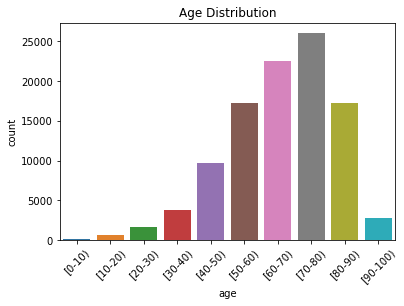

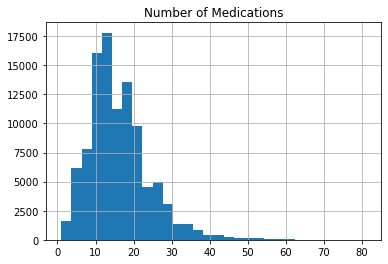

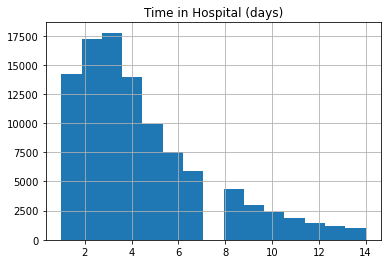

In [12]:
# Individual plots
# Age distribution
sns.countplot(data=df, x="age")
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

# Number of medications
df["num_medications"].hist(bins=30)
plt.title("Number of Medications")
plt.show()

# Time in hospital
df["time_in_hospital"].hist(bins=15)
plt.title("Time in Hospital (days)")
plt.show()

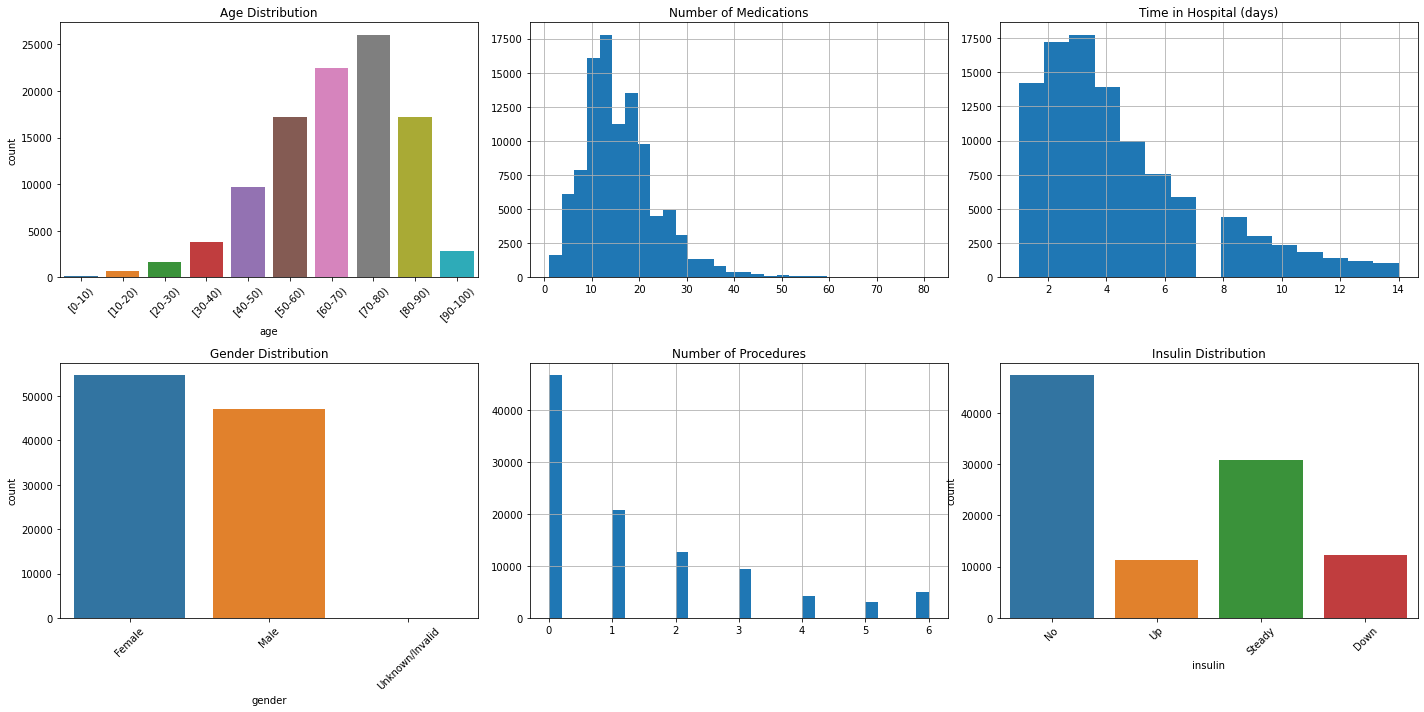

In [13]:
# Grid plots- side by side
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 3 columns

# Plot 1
sns.countplot(data = df, x="age", ax=axes[0][0])
axes[0][0].set_title("Age Distribution")
axes[0][0].tick_params(axis='x', rotation=45)

# Plot 2
df["num_medications"].hist(bins=30, ax=axes[0][1])
axes[0][1].set_title("Number of Medications")

# Plot 3
df["time_in_hospital"].hist(bins=15, ax=axes[0][2])
axes[0][2].set_title("Time in Hospital (days)")

# Plot 4
sns.countplot(data = df, x="gender", ax=axes[1][0])
axes[1][0].set_title("Gender Distribution")
axes[1][0].tick_params(axis='x', rotation=45)


# Plot 5
df["num_procedures"].hist(bins=30, ax=axes[1][1])
axes[1][1].set_title("Number of Procedures")
plt.tight_layout()

# Plot 6
sns.countplot(data = df, x="insulin", ax=axes[1][2])
axes[1][2].set_title("Insulin Distribution")
axes[1][2].tick_params(axis='x', rotation=45)

plt.show()

## Observations
### 1. Most patients are in the age range of 70-80
### 2. Number of medications distribution is right skewed- longer tail on right side
### 3. Most patients spend less than 6 days in hospital
### 4. Females are more compared to Males
### 5. Atleast half of the patients do not have any procedures done
### 6. No insulin or steady insulin is given for most of the patients

In [14]:
missing_df = (df== "?").sum()
missing_df = (missing_df/len(df))*100
print(missing_df[missing_df > 0].sort_values(ascending = False))

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


### Note: weight, medical_specialty, payer_code have highest amount of missing data(which is present as ? in data)

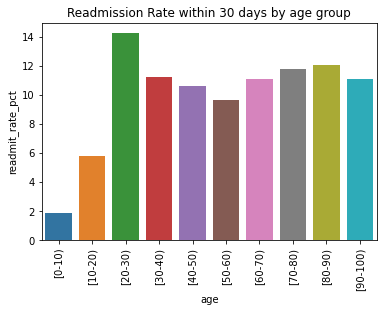

In [15]:
readmit_by_age = df.groupby("age")["readmitted"].apply(lambda x:(x=="<30").mean()*100).reset_index()
readmit_by_age.columns = ("age", "readmit_rate_pct")
sns.barplot(data = readmit_by_age, x="age", y="readmit_rate_pct")
plt.title("Readmission Rate within 30 days by age group")
plt.xticks(rotation=90)
plt.show()

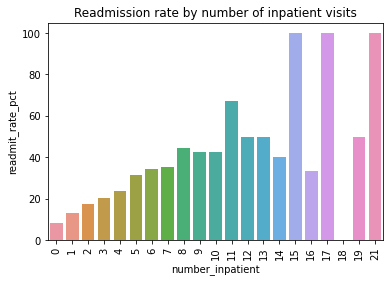

In [16]:
readmit_by_inpatient = df.groupby("number_inpatient")["readmitted"].apply(lambda x:(x=="<30").mean()*100).reset_index()
readmit_by_inpatient.columns = ("number_inpatient", "readmit_rate_pct")
sns.barplot(data = readmit_by_inpatient, x= "number_inpatient", y= "readmit_rate_pct")
plt.title("Readmission rate by number of inpatient visits")
plt.xticks(rotation = 90)
plt.show()

## More prior visits much likely to be readmitted

In [17]:
## Remove variables with high ? values
df= df.drop(columns = ["weight", "medical_specialty", "payer_code"]).copy()

In [18]:
df = df.replace("?", np.nan).copy()

In [19]:
print(df.isnull().sum()[df.isnull().sum()>0])

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [20]:
df["race"] = df["race"].fillna("Unknown")

In [21]:
df = df.dropna(subset = ["diag_1", "diag_2", "diag_3"]).copy()

In [22]:
df = df.drop(columns=["encounter_id", "patient_nbr"]).copy()

In [23]:
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)
print(df["readmitted_binary"].value_counts())

0    88994
1    11250
Name: readmitted_binary, dtype: int64


In [24]:
df["total_services"] = (df["num_lab_procedures"]+df["num_procedures"]+df["number_diagnoses"]+df["num_medications"])

In [25]:
print(df.groupby("readmitted")["total_services"].mean())

readmitted
<30    70.240444
>30    69.188980
NO     67.013229
Name: total_services, dtype: float64


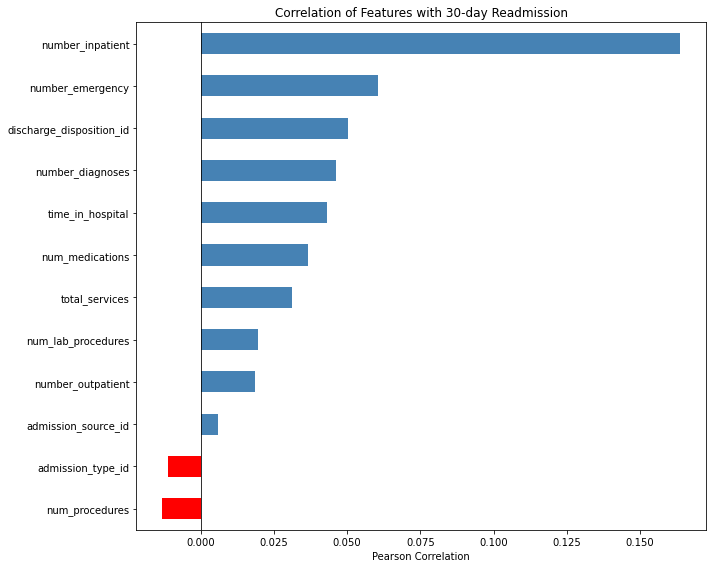

In [26]:
# Bar chart answer: "what predicts readmission specifically?"
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_with_target = df[numeric_cols].corr()["readmitted_binary"].drop("readmitted_binary").sort_values()

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind="barh", color=["red" if x < 0 else "steelblue" for x in corr_with_target])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Features with 30-day Readmission")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

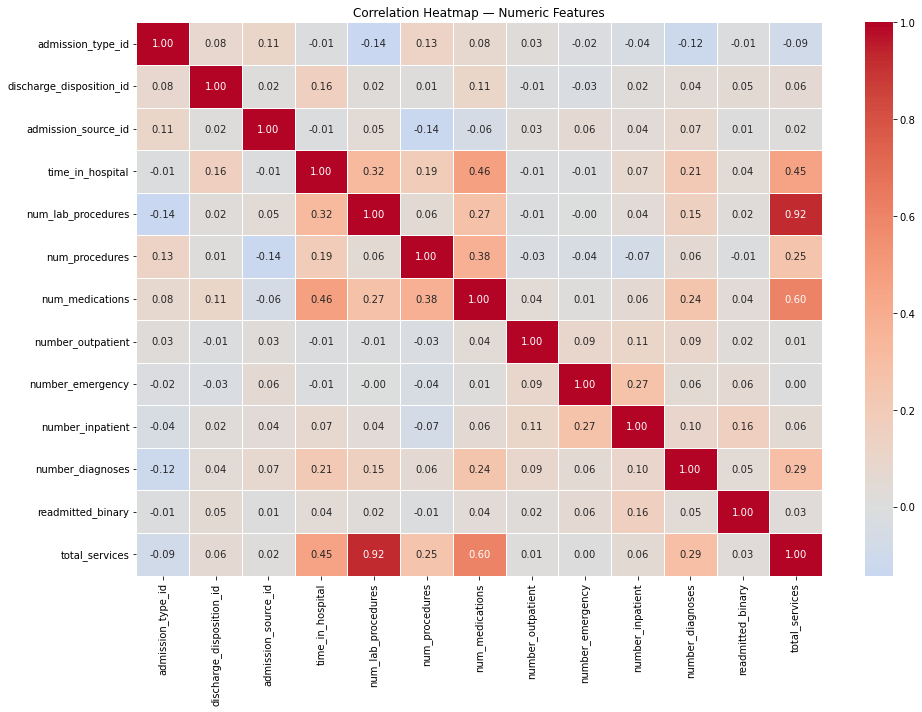

In [27]:
# Heatmap answer:  "how does everything relate to everything?"
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

In [28]:
df.to_csv("diabetic_data_cleaned.csv", index=False)
print("Cleaned data:", df.shape)

Cleaned data: (100244, 47)


## Summary - 06/11
### Columns dropped and why - "encounter_id", "patient_nbr", "weight", "medical_specialty", "payer_code" are dropped
### How missing values were handled - Parameters with high amount of missing values are dropped like weight", "medical_specialty", "payer_code" and parameter "race" with less amount of missing data(indicated as ?) is replaced with null values, and for some parameters like diag_1, diag_2, diag_3 - missing values are dropped
### New features engineered - readmitted_binary - to convert readmitted parameter into binary data(1 if <30 and 0 for others), total_services new parameter added by adding few other parameters
### Final shape of the cleaned dataset- 100244 * 47

# 06/18- Linear Regression

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [30]:
df = pd.read_csv('diabetic_data_cleaned.csv')
print(df.shape)

(100244, 47)


In [31]:
print(df[['time_in_hospital', 'num_lab_procedures', 
          'num_procedures', 'number_diagnoses', 'total_services']].describe())

       time_in_hospital  num_lab_procedures  num_procedures  number_diagnoses  \
count     100244.000000       100244.000000   100244.000000     100244.000000   
mean           4.420275           43.173716        1.350275          7.497007   
std            2.991273           19.691484        1.710913          1.839537   
min            1.000000            1.000000        0.000000          3.000000   
25%            2.000000           32.000000        0.000000          6.000000   
50%            4.000000           44.000000        1.000000          8.000000   
75%            6.000000           57.000000        2.000000          9.000000   
max           14.000000          132.000000        6.000000         16.000000   

       total_services  
count   100244.000000  
mean        68.138821  
std         24.064395  
min          6.000000  
25%         53.000000  
50%         68.000000  
75%         84.000000  
max        187.000000  


In [32]:
print(df.select_dtypes(include='number').columns.tolist())

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted_binary', 'total_services']


In [33]:
features = ['time_in_hospital', 'num_procedures', 'number_diagnoses', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient']

X = df[features].drop(columns=['time_in_hospital'])
y = df['time_in_hospital']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (80195, 6)
Test size: (20049, 6)


In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'R²: {r2_score(y_test, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')

R²: 0.229
RMSE: 2.650


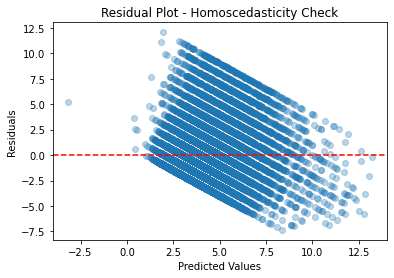

C:\Users\madhu\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


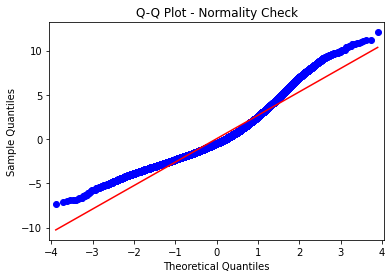

In [35]:
## Checking Homoskedasticity and Normality- linear regression assumptions
residuals = y_test - y_pred

# Residual plot
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Homoscedasticity Check')
plt.show()

# Q-Q plot
import statsmodels.api as sm
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot - Normality Check')
plt.show()

In [36]:
# Checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) 
                   for i in range(X_train.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

             feature       VIF
2    num_medications  5.953357
1   number_diagnoses  5.236118
0     num_procedures  1.922652
5   number_inpatient  1.384429
4   number_emergency  1.131409
3  number_outpatient  1.112491


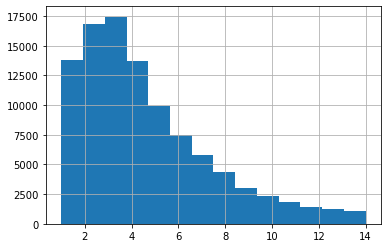

In [37]:
df['time_in_hospital'].hist(bins=14)
plt.show()
# Right skewed- fix is log transform

In [38]:
# Using log transform for y
import statsmodels.api as sm

# Original residuals
model_orig = LinearRegression()
model_orig.fit(X_train, y_train)
residuals_orig = y_test - model_orig.predict(X_test)

# Log transformed
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)
residuals_log = y_test_log - model_log.predict(X_test)

C:\Users\madhu\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
C:\Users\madhu\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


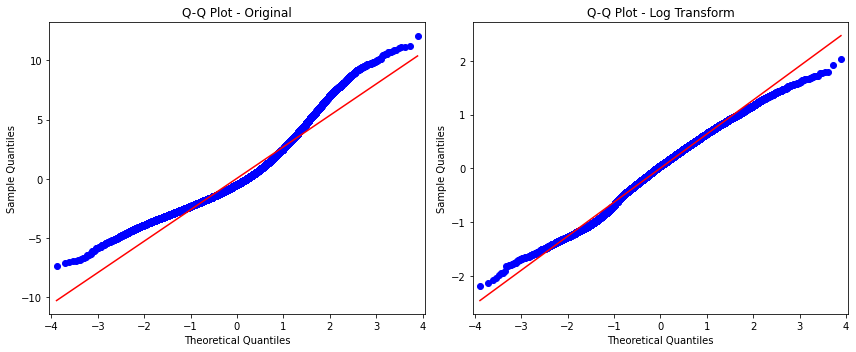

In [39]:
# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(residuals_orig, line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot - Original')

sm.qqplot(residuals_log, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot - Log Transform')

plt.tight_layout()
plt.show()

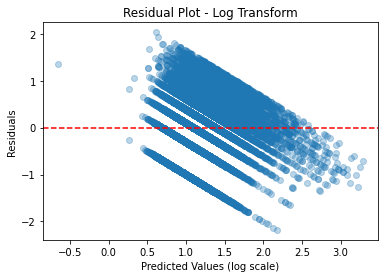

In [40]:
## Homoskedasticity check after log transform
residuals_log = y_test_log - model_log.predict(X_test)
y_pred_log = model_log.predict(X_test)

plt.scatter(y_pred_log, residuals_log, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (log scale)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Log Transform')
plt.show()

***Note:***
- VIF need not be plotted with log transform data since VIF is for only independent features and not dependent variables

## Linear Regression - Findings

**Target:** time_in_hospital
**Features:** num_procedures, number_diagnoses, num_medications, 
              number_outpatient, number_emergency, number_inpatient

**Model Performance:**
- R²: 0.229 — model explains 23% of variance in hospital stay length
- RMSE: 2.65 — predictions off by ~2.6 days on average

## Linear Regression - Findings

**Assumption Checks:**
- Homoscedasticity ✅ — residuals evenly spread
- Normality ❌ on original target → ✅ after log transform
- Multicollinearity — total_services dropped (VIF 13.3), 
                      remaining features all below 6

**Conclusion:**
Log transforming time_in_hospital fixes normality. 
Use log-transformed model for inference.
For prediction, exponentiate output back: np.exp(y_pred_log)

## Project 1 Summary - Week 2

### EDA Findings
- Dataset: 100,244 patients, 47 features after cleaning
- Key predictors of readmission: number_inpatient, num_medications, number_diagnoses
- Readmitted patients: ~11% of dataset

### Linear Regression - time_in_hospital
- R²: 0.229, RMSE: 2.65
- Homoscedasticity ✅
- Normality ❌ → fixed with log transform ✅
- Multicollinearity: dropped total_services (VIF 13.3)
- Conclusion: Poisson regression or tree-based model better suited

### Next Step
- Week 3: Build logistic regression classifier for readmission_binary

In [41]:
from scipy import stats

readmitted = df[df['readmitted_binary'] == 1]['time_in_hospital']
not_readmitted = df[df['readmitted_binary'] == 0]['time_in_hospital']

t_stat, p_value = stats.ttest_ind(readmitted, not_readmitted)
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Readmitted mean stay: {readmitted.mean():.2f} days')
print(f'Not readmitted mean stay: {not_readmitted.mean():.2f} days')

t-statistic: 13.671
p-value: 0.0000
Readmitted mean stay: 4.78 days
Not readmitted mean stay: 4.37 days


In [42]:
from scipy.stats import ttest_ind

cohens_d = (readmitted.mean() - not_readmitted.mean()) / readmitted.std()
print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 0.135


## Hypothesis Testing - t-test Results

**Question:** Do readmitted patients stay longer in hospital?

**H₀:** No difference in mean stay between readmitted and non-readmitted patients
**H₁:** Readmitted patients have longer mean stay

**Results:**
- t-statistic: 13.671
- p-value: ~0.0000 → reject H₀
- Readmitted mean: 4.78 days
- Not readmitted mean: 4.37 days
- Difference: 0.41 days
- Cohen's d: 0.135 → small effect

**Conclusion:**
Statistically significant but not clinically meaningful.
With 100K rows, even tiny differences produce very low p-values.
Always report effect size alongside p-value.


# Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler

features = ['num_procedures', 'number_diagnoses', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient']

X = df[features]
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Class distribution:\n{y.value_counts(normalize=True)}')

Class distribution:
0    0.887774
1    0.112226
Name: readmitted_binary, dtype: float64


In [44]:
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [45]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}')

Accuracy:  0.696
Precision: 0.174
Recall:    0.463
F1:        0.253
ROC-AUC:   0.629


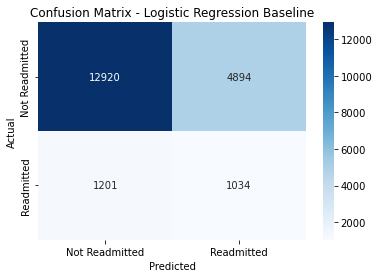

In [46]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.show()

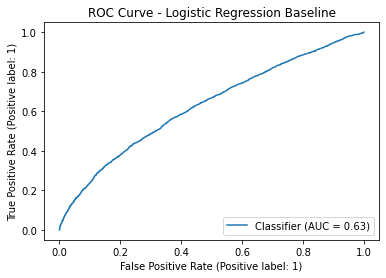

In [47]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve - Logistic Regression Baseline')
plt.show()

## Project 1 - Logistic Regression Baseline

**Model:** Logistic Regression (class_weight='balanced')
**Features:** 7 numeric features only
**Target:** readmitted_binary (11% positive class)

**Results:**
- Accuracy: 0.696
- Precision: 0.174
- Recall: 0.463
- F1: 0.253
- ROC-AUC: 0.629

**Confusion Matrix:**
- True Positives: 1,034
- False Negatives: 1,201 (missed high-risk patients)
- False Positives: 4,894 (false alarms)

**Next Step:** Add encoded categorical features (age, insulin, 
medications) to improve recall and AUC

# Logistic regression modified

In [48]:
print(df.select_dtypes(include='object').columns.tolist())

['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [49]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


race:
Caucasian          75079
AfricanAmerican    18881
Unknown             2191
Hispanic            1984
Other               1484
Asian                625
Name: race, dtype: int64

gender:
Female             53922
Male               46319
Unknown/Invalid        3
Name: gender, dtype: int64

age:
[70-80)     25898
[60-70)     22288
[80-90)     17090
[50-60)     17044
[40-50)      9474
[30-40)      3616
[90-100)     2785
[20-30)      1515
[10-20)       469
[0-10)         65
Name: age, dtype: int64

diag_1:
428    6853
414    6546
786    3977
410    3610
486    3495
       ... 
216       1
V43       1
838       1
955       1
V51       1
Name: diag_1, Length: 715, dtype: int64

diag_2:
428     6657
276     6622
250     5584
427     5022
401     3705
        ... 
944        1
E919       1
E829       1
953        1
927        1
Name: diag_2, Length: 743, dtype: int64

diag_3:
250     11533
401      8281
276      5172
428      4572
427      3949
        ...  
E945        1
853         1
542

In [50]:
# race, gender, age, max_glu_serum, A1Cresult, metformin,  glimepiride, glipizide, glyburide, pioglitazone, rosiglitazone, insulin
#change, diabetesMed
# mostly no- repaglinide, nateglinide, chlorpropamide, acetohexamide, tolbutamide, acarbose, miglitol, troglitazone, tolazamide, examide, citoglipton
#  glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone

In [51]:
# Ordinal
ordinal_cols = ['age', 'max_glu_serum', 'A1Cresult']

# Binary
binary_cols = ['gender', 'change', 'diabetesMed']

# One-hot (No/Steady/Up/Down)
onehot_cols = ['race', 'metformin', 'glimepiride', 'glipizide', 
               'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']

In [52]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

df['age_encoded'] = df['age'].map(
    {age: i for i, age in enumerate(age_order)})

print(df['age_encoded'].value_counts().sort_index())

0       65
1      469
2     1515
3     3616
4     9474
5    17044
6    22288
7    25898
8    17090
9     2785
Name: age_encoded, dtype: int64


In [53]:
# Ordinal encoding for max_glu_serum and A1Cresult
glu_order = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_order = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}

df['max_glu_serum_encoded'] = df['max_glu_serum'].map(glu_order)
df['A1Cresult_encoded'] = df['A1Cresult'].map(a1c_order)

# Binary encoding
df['gender_encoded'] = (df['gender'] == 'Male').astype(int)
df['change_encoded'] = (df['change'] == 'Ch').astype(int)
df['diabetesMed_encoded'] = (df['diabetesMed'] == 'Yes').astype(int)

# One-hot encoding
onehot_cols = ['race', 'metformin', 'glimepiride', 'glipizide',
               'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print(df_encoded.shape)

(100244, 71)


In [55]:
# New feature list
numeric_features = ['num_procedures', 'number_diagnoses', 'num_medications',
                    'number_outpatient', 'number_emergency', 'number_inpatient',
                    'time_in_hospital']

encoded_features = ['age_encoded', 'max_glu_serum_encoded', 'A1Cresult_encoded',
                    'gender_encoded', 'change_encoded', 'diabetesMed_encoded']

# Get one-hot encoded column names
onehot_features = [col for col in df_encoded.columns 
                   if any(col.startswith(x) for x in 
                   ['race_', 'metformin_', 'glimepiride_', 'glipizide_',
                    'glyburide_', 'pioglitazone_', 'rosiglitazone_', 'insulin_'])]

all_features = numeric_features + encoded_features + onehot_features

X = df_encoded[all_features]
y = df_encoded['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_full = LogisticRegression(class_weight='balanced', 
                                random_state=42, max_iter=1000)
model_full.fit(X_train_scaled, y_train)

y_pred_full = model_full.predict(X_test_scaled)
y_prob_full = model_full.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_full):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_full):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_full):.3f}')
print(f'F1:        {f1_score(y_test, y_pred_full):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_full):.3f}')

Accuracy:  0.672
Precision: 0.174
Recall:    0.516
F1:        0.260
ROC-AUC:   0.639


## Project 1 - Feature Engineering & Full Logistic Regression Model

### Features Added
- **Ordinal encoded:** age (0-9), max_glu_serum (0-3), A1Cresult (0-3)
- **Binary encoded:** gender, change, diabetesMed
- **One-hot encoded:** race, metformin, glimepiride, glipizide, glyburide, pioglitazone, rosiglitazone, insulin
- **Dropped:** rare medication columns with mostly 'No' values (near-zero variance)
- **Total features:** 7 numeric + encoded categorical = ~35 features

### Feature Engineering Decisions
- Used ordinal encoding for age — natural order exists (higher age = higher risk)
- Used one-hot encoding for medications — no natural order between No/Steady/Up/Down
- Dropped first category in one-hot to avoid multicollinearity (drop_first=True)

### Model Comparison
| Metric    | Baseline (7 features) | Full Model (35 features) |
|-----------|----------------------|--------------------------|
| Accuracy  | 0.696                | 0.672                    |
| Precision | 0.174                | 0.174                    |
| Recall    | 0.463                | 0.516                    |
| F1        | 0.253                | 0.260                    |
| ROC-AUC   | 0.629                | 0.639                    |

### Key Findings
- Recall improved from 46% → 52% — model catches more high-risk patients
- AUC improved slightly from 0.629 → 0.639
- Class imbalance (89% vs 11%) handled with class_weight='balanced'
- Logistic regression is a good baseline but limited — next step is 
  tree-based models (Random Forest, XGBoost) which should push AUC above 0.70

### Next Step
Week 3: Build Random Forest and XGBoost classifiers on same dataset
and compare against logistic regression baseline

In [56]:
# All categorical columns one-hot encoded
all_onehot_cols = ['race', 'metformin', 'repaglinide', 'nateglinide', 
                   'chlorpropamide', 'glimepiride', 'acetohexamide',
                   'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 
                   'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 
                   'tolazamide', 'examide', 'citoglipton', 'insulin',
                   'glyburide-metformin', 'glipizide-metformin', 
                   'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
                   'metformin-pioglitazone']

df_all = pd.get_dummies(df, columns=all_onehot_cols, drop_first=True)

# Add ordinal and binary encoded columns from before
df_all['age_encoded'] = df['age_encoded']
df_all['max_glu_serum_encoded'] = df['max_glu_serum_encoded']
df_all['A1Cresult_encoded'] = df['A1Cresult_encoded']
df_all['gender_encoded'] = df['gender_encoded']
df_all['change_encoded'] = df['change_encoded']
df_all['diabetesMed_encoded'] = df['diabetesMed_encoded']

# All features
all_onehot_features = [col for col in df_all.columns 
                       if any(col.startswith(x) for x in all_onehot_cols)]

all_features_full = numeric_features + encoded_features + all_onehot_features

X_all = df_all[all_features_full]
y_all = df_all['readmitted_binary']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

model_all = LogisticRegression(class_weight='balanced', 
                               random_state=42, max_iter=1000)
model_all.fit(X_train_all_scaled, y_train_all)

y_pred_all = model_all.predict(X_test_all_scaled)
y_prob_all = model_all.predict_proba(X_test_all_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test_all, y_pred_all):.3f}')
print(f'Precision: {precision_score(y_test_all, y_pred_all):.3f}')
print(f'Recall:    {recall_score(y_test_all, y_pred_all):.3f}')
print(f'F1:        {f1_score(y_test_all, y_pred_all):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test_all, y_prob_all):.3f}')

Accuracy:  0.671
Precision: 0.173
Recall:    0.516
F1:        0.259
ROC-AUC:   0.639


## Model Comparison - Feature Selection Impact

| Metric    | Baseline (7 features) | Selected Features | All Features |
|-----------|----------------------|-------------------|--------------|
| Accuracy  | 0.696                | 0.672             | 0.671        |
| Precision | 0.174                | 0.174             | 0.173        |
| Recall    | 0.463                | 0.516             | 0.516        |
| F1        | 0.253                | 0.260             | 0.259        |
| ROC-AUC   | 0.629                | 0.639             | 0.639        |

### Conclusion
Adding low-variance (mostly 'No') columns made virtually no difference 
to model performance. Selected features model chosen as final baseline 
following Occam's razor — prefer simpler models when performance is equal.

### Key Insight
Feature selection based on domain knowledge (dropping near-zero variance 
columns) produced the same result as using all features, while keeping 
the model interpretable and faster to train.